
# Asphalt Crack Detection using Traditional Machine Learning

### Objective
Convert road images into handcrafted numerical features using OpenCV/NumPy and classify them as:

- `1 = Crack`
- `0 = Non-Crack`

### Pipeline

**Images → Preprocessing → Feature Extraction → Feature Table → Train/Test Split → Traditional ML Classifiers → Evaluation**

Feature groups used:
1. NumPy intensity/statistical features
2. Canny edge features
3. Black Hat morphological features
4. Optional Hough features



## Part 1 — Imports, dataset paths, labels, and image loading

The folder structure is assumed to be:

```text
Asphalt Crack Dataset/
├── Crack/
└── Non-Crack/
```

The folder itself provides the ground-truth label. We do **not** derive the target from image features.


In [2]:
!pip install opencv-python

   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
    --------------------------------------- 1.0/44.0 MB 6.3 MB/s eta 0:00:07
   -- ------------------------------------- 2.4/44.0 MB 6.7 MB/s eta 0:00:07
   --- ------------------------------------ 3.9/44.0 MB 7.1 MB/s eta 0:00:06
   ----- ---------------------------------- 5.5/44.0 MB 7.3 MB/s eta 0:00:06
   ------ --------------------------------- 7.1/44.0 MB 7.3 MB/s eta 0:00:06
   ------ --------------------------------- 7.6/44.0 MB 7.0 MB/s eta 0:00:06
   ------- -------------------------------- 8.4/44.0 MB 6.2 MB/s eta 0:00:06
   -------- ------------------------------- 9.4/44.0 MB 6.0 MB/s eta 0:00:06
   --------- ------------------------------ 10.2/44.0 MB 5.6 MB/s eta 0:00:06
   --------- ------------------------------ 10.7/44.0 MB 5.5 MB/s eta 0:00:07
   ---------- ----------------------------- 11.0/44.0 MB 5.3 MB/s eta 0:00:07
   ---------- ----------------------------- 11.8/44.0 MB 4.9 MB/s eta 0:00:07
  

In [4]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1. SET DATASET PATH
# ============================================================

DATASET_PATH = r"C:\Users\Yatri\Desktop\ml_lab06\xnzhj3x8v4-1\448"

CRACK_PATH = os.path.join(DATASET_PATH, "cracks")
NON_CRACK_PATH = os.path.join(DATASET_PATH, "noncracks")

print("Dataset:", DATASET_PATH)
print("Crack folder:", CRACK_PATH)
print("Non-crack folder:", NON_CRACK_PATH)

print("Crack folder exists:", os.path.exists(CRACK_PATH))
print("Non-crack folder exists:", os.path.exists(NON_CRACK_PATH))


# ============================================================
# 2. GET FILENAMES FROM BOTH FOLDERS
# ============================================================

crack_files = os.listdir(CRACK_PATH)
non_crack_files = os.listdir(NON_CRACK_PATH)

print("\nNumber of files in cracks folder:", len(crack_files))
print("Number of files in noncracks folder:", len(non_crack_files))


# ============================================================
# 3. CREATE IMAGE PATHS AND TARGET LABELS
# ============================================================

image_paths = []
labels = []

# Crack images → target = 1
for filename in crack_files:
    filepath = os.path.join(CRACK_PATH, filename)

    if os.path.isfile(filepath):
        image_paths.append(filepath)
        labels.append(1)

# Non-crack images → target = 0
for filename in non_crack_files:
    filepath = os.path.join(NON_CRACK_PATH, filename)

    if os.path.isfile(filepath):
        image_paths.append(filepath)
        labels.append(0)


# ============================================================
# 4. CREATE DATAFRAME
# ============================================================

df = pd.DataFrame({
    "image_path": image_paths,
    "target": labels
})

print("\nTotal images:", len(df))

print("\nClass distribution:")
print(df["target"].value_counts())

display(df.head())

Dataset: C:\Users\Yatri\Desktop\ml_lab06\xnzhj3x8v4-1\448
Crack folder: C:\Users\Yatri\Desktop\ml_lab06\xnzhj3x8v4-1\448\cracks
Non-crack folder: C:\Users\Yatri\Desktop\ml_lab06\xnzhj3x8v4-1\448\noncracks
Crack folder exists: True
Non-crack folder exists: True

Number of files in cracks folder: 200
Number of files in noncracks folder: 200

Total images: 400

Class distribution:
target
1    200
0    200
Name: count, dtype: int64


,image_path,target
0,C:\Users\Yatri\Desktop\ml_lab06\xnzhj3x8v4-1\4...,1
1,C:\Users\Yatri\Desktop\ml_lab06\xnzhj3x8v4-1\4...,1
2,C:\Users\Yatri\Desktop\ml_lab06\xnzhj3x8v4-1\4...,1
3,C:\Users\Yatri\Desktop\ml_lab06\xnzhj3x8v4-1\4...,1
4,C:\Users\Yatri\Desktop\ml_lab06\xnzhj3x8v4-1\4...,1


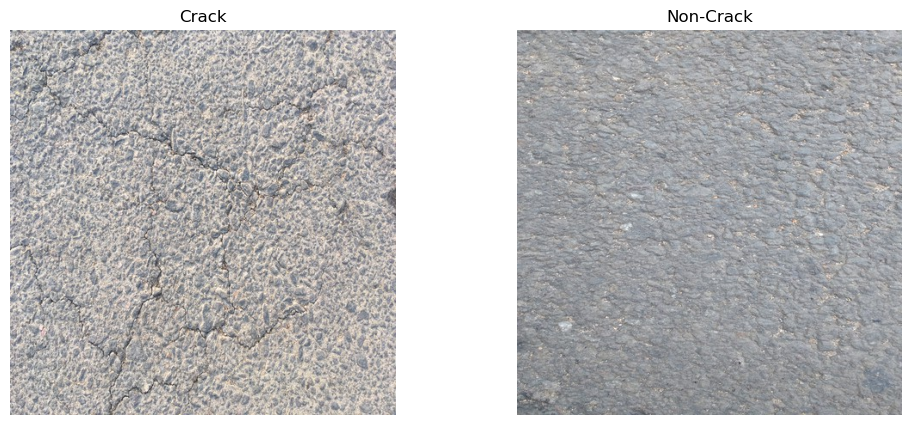

In [47]:

# Visual inspection of one Crack and one Non-Crack image

crack_sample = df[df["target"] == 1].iloc[150]["image_path"]
non_crack_sample = df[df["target"] == 0].iloc[0]["image_path"]

crack_img = cv2.cvtColor(cv2.imread(crack_sample), cv2.COLOR_BGR2RGB)
non_crack_img = cv2.cvtColor(cv2.imread(non_crack_sample), cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(crack_img)
plt.title("Crack")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(non_crack_img)
plt.title("Non-Crack")
plt.axis("off")

plt.show()



## Part 2 — Image preprocessing

Every image can have a different resolution. We therefore resize all images to a common size.

We then:
1. Convert BGR → grayscale
2. Apply Gaussian blur to reduce tiny texture/noise before Canny


In [48]:

IMG_SIZE = (256, 256)

def preprocess_image(image_path, img_size=IMG_SIZE):
    image = cv2.imread(image_path)

    if image is None:
        raise ValueError(f"Could not read image: {image_path}")

    resized = cv2.resize(image, img_size)
    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)

    # Reduce very small texture/noise before edge detection
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    return resized, gray, blurred


sample_color, sample_gray, sample_blurred = preprocess_image(crack_sample)

print("Original/resized image shape:", sample_color.shape)
print("Grayscale shape:", sample_gray.shape)


Original/resized image shape: (256, 256, 3)
Grayscale shape: (256, 256)


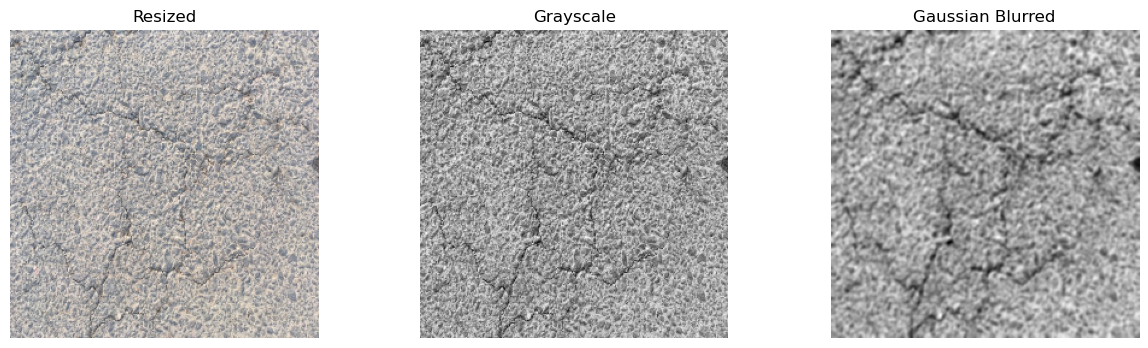

In [49]:

# Visualize preprocessing

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(sample_color, cv2.COLOR_BGR2RGB))
plt.title("Resized")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(sample_gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(sample_blurred, cmap="gray")
plt.title("Gaussian Blurred")
plt.axis("off")

plt.show()



## Part 3 — NumPy intensity/statistical features

These describe the overall pixel-intensity characteristics of the road surface.

Features:
- Mean brightness
- Contrast (`standard deviation`)
- Minimum intensity
- Maximum intensity
- Dark-pixel ratio
- Bright-pixel ratio


In [50]:

def extract_intensity_features(gray):
    features = {}

    features["mean_brightness"] = np.mean(gray)
    features["contrast_std"] = np.std(gray)
    features["min_intensity"] = np.min(gray)
    features["max_intensity"] = np.max(gray)

    # Thresholds are feature definitions, not crack labels
    features["dark_pixel_ratio"] = np.mean(gray < 60)
    features["bright_pixel_ratio"] = np.mean(gray > 200)

    return features


intensity_demo = extract_intensity_features(sample_gray)
intensity_demo


{'mean_brightness': np.float64(170.62660217285156),
 'contrast_std': np.float64(27.920521218146238),
 'min_intensity': np.uint8(52),
 'max_intensity': np.uint8(249),
 'dark_pixel_ratio': np.float64(4.57763671875e-05),
 'bright_pixel_ratio': np.float64(0.1504058837890625)}


## Part 4 — Canny edge features

Canny detects intensity boundaries. It is **not itself a crack classifier**.

To reduce the influence of tiny texture:
- Gaussian blur is applied first.
- Canny thresholds are used to control sensitivity.
- Connected components are then used to remove very small edge components.

We extract:
- Raw edge density
- Number of significant edge components
- Significant edge pixel ratio
- Largest significant edge component


In [51]:

# Canny parameters — these can be tuned later
CANNY_LOW = 50
CANNY_HIGH = 150

# Components smaller than this are ignored
MIN_EDGE_COMPONENT_AREA = 20


def extract_canny_features(blurred):
    edges = cv2.Canny(blurred, CANNY_LOW, CANNY_HIGH)

    # Raw edge density
    edge_density = np.mean(edges > 0)

    # Find connected edge components
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
        (edges > 0).astype(np.uint8),
        connectivity=8
    )

    component_areas = stats[1:, cv2.CC_STAT_AREA]  # exclude background
    significant_areas = component_areas[
        component_areas >= MIN_EDGE_COMPONENT_AREA
    ]

    if len(significant_areas) == 0:
        num_significant = 0
        significant_pixels = 0
        largest_component = 0
    else:
        num_significant = len(significant_areas)
        significant_pixels = np.sum(significant_areas)
        largest_component = np.max(significant_areas)

    total_pixels = edges.shape[0] * edges.shape[1]

    features = {
        "edge_density": edge_density,
        "num_significant_edge_components": num_significant,
        "significant_edge_pixel_ratio": significant_pixels / total_pixels,
        "largest_edge_component": largest_component
    }

    return features, edges


canny_demo, demo_edges = extract_canny_features(sample_blurred)

print(canny_demo)


{'edge_density': np.float64(0.274993896484375), 'num_significant_edge_components': 129, 'significant_edge_pixel_ratio': np.float64(0.265106201171875), 'largest_edge_component': np.int32(4185)}


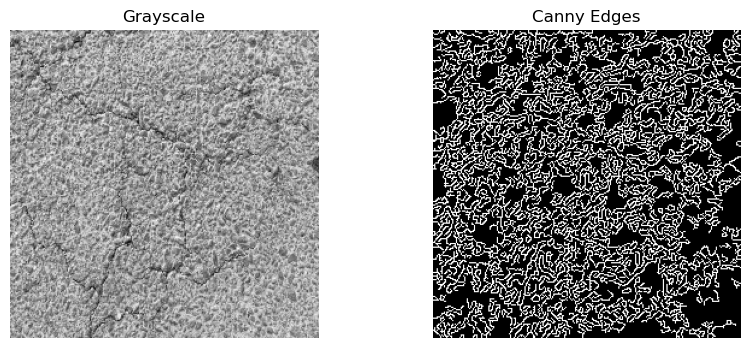

In [52]:

# Visualize Canny result

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(sample_gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(demo_edges, cmap="gray")
plt.title("Canny Edges")
plt.axis("off")

plt.show()



## Part 5 — Black Hat morphological features

Black Hat morphology emphasizes dark structures relative to their surroundings.

\[
BlackHat(I) = Closing(I) - I
\]

This is useful as a complementary representation because road cracks can appear as dark, narrow structures.

We do **not** use Black Hat to manually decide whether an image is a crack. We only extract numerical features from its response.


In [53]:
# ---- Parameters (tune these on a few crack AND non-crack images) ----
BH_BLUR_SIGMA = 5        # higher = removes more grain (try 3.5 to 6)
BH_KERNEL_SIZE = 21      # match crack width (try 21, 31); bigger catches wider dark bands
BLACKHAT_THRESHOLD = 8   # ABSOLUTE threshold on the response (try 6 to 12)
MIN_CRACK_LENGTH = 40    # keep only components at least this long (px)

blackhat_kernel = cv2.getStructuringElement(
    cv2.MORPH_ELLIPSE, (BH_KERNEL_SIZE, BH_KERNEL_SIZE)
)
close_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))


def blackhat_clean(gray):
    g = gray.astype(np.float32)

    # 1. Remove uneven lighting (subtract a very blurry background)
    flat = g - cv2.GaussianBlur(g, (0, 0), 30)
    flat = np.clip(flat + 128, 0, 255).astype(np.uint8)

    # 2. Kill asphalt grain: median filter, then strong Gaussian
    smooth = cv2.medianBlur(flat, 5)
    smooth = cv2.GaussianBlur(smooth, (0, 0), BH_BLUR_SIGMA)

    # 3. Black Hat on the heavily smoothed image
    bh = cv2.morphologyEx(smooth, cv2.MORPH_BLACKHAT, blackhat_kernel)

    # 4. Fixed threshold: a crack-free image gives an (almost) empty mask
    mask = (bh > BLACKHAT_THRESHOLD).astype(np.uint8) * 255

    # 5. Bridge small gaps
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, close_kernel)

    # 6. Keep only LONG components (grain blobs are short, cracks are long)
    n, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    clean = np.zeros_like(mask)
    for i in range(1, n):
        w = stats[i, cv2.CC_STAT_WIDTH]
        h = stats[i, cv2.CC_STAT_HEIGHT]
        if max(w, h) >= MIN_CRACK_LENGTH:
            clean[labels == i] = 255

    return bh, clean


def extract_blackhat_features(gray):
    bh, clean = blackhat_clean(gray)

    n, _, stats, _ = cv2.connectedComponentsWithStats(clean, connectivity=8)
    areas = stats[1:, cv2.CC_STAT_AREA]

    features = {
        "blackhat_mean": np.mean(bh),
        "blackhat_std": np.std(bh),
        "blackhat_max": np.max(bh),
        "blackhat_pixel_ratio": np.mean(clean > 0),
        "blackhat_num_components": len(areas),
        "blackhat_largest_component": areas.max() if len(areas) else 0,
    }
    return features, bh, clean


blackhat_demo, demo_blackhat, demo_blackhat_mask = extract_blackhat_features(sample_gray)
print(blackhat_demo)

{'blackhat_mean': np.float64(2.0162353515625), 'blackhat_std': np.float64(2.718903567372727), 'blackhat_max': np.uint8(28), 'blackhat_pixel_ratio': np.float64(0.0), 'blackhat_num_components': 0, 'blackhat_largest_component': 0}


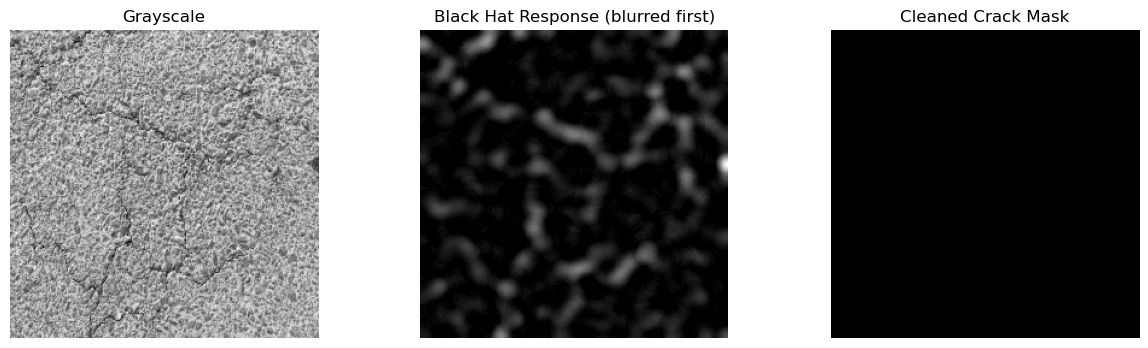

In [54]:
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(sample_gray, cmap="gray"); plt.title("Grayscale"); plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(demo_blackhat, cmap="gray"); plt.title("Black Hat Response (blurred first)"); plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(demo_blackhat_mask, cmap="gray"); plt.title("Cleaned Crack Mask"); plt.axis("off")

plt.show()


## Part 6 — Optional Hough features

Hough Transform detects line-like structures. Cracks are not necessarily straight, so Hough should be treated as an **optional feature family**, not the main crack detector.

We will extract:
- Number of detected line segments
- Average line length
- Maximum line length

These features can later be compared with and without Hough.


In [55]:
HOUGH_THRESHOLD = 50
HOUGH_MIN_LINE_LENGTH = 20
HOUGH_MAX_LINE_GAP = 10


def extract_hough_features(edges):
    
    lines = cv2.HoughLinesP(
        edges,
        rho=1,
        theta=np.pi / 180,
        threshold=HOUGH_THRESHOLD,
        minLineLength=HOUGH_MIN_LINE_LENGTH,
        maxLineGap=HOUGH_MAX_LINE_GAP
    )

    # No lines detected
    if lines is None:
        return {
            "hough_line_count": 0,
            "hough_avg_line_length": 0,
            "hough_max_line_length": 0
        }

    lengths = []

    for line in lines:
        # Flatten the line so it works with different OpenCV array shapes
        x1, y1, x2, y2 = line.ravel()

        length = np.sqrt(
            (x2 - x1)**2 + (y2 - y1)**2
        )

        lengths.append(length)

    return {
        "hough_line_count": len(lengths),
        "hough_avg_line_length": np.mean(lengths),
        "hough_max_line_length": np.max(lengths)
    }


# Test Hough feature extraction
hough_demo = extract_hough_features(demo_edges)

print(hough_demo)

{'hough_line_count': 287, 'hough_avg_line_length': np.float64(116.23037374449224), 'hough_max_line_length': np.float64(322.44069222106566)}



## Part 7 — Extract all features for every image

Now we combine all the feature-extraction functions.

For each image:

**Image → resize → grayscale → blur → intensity features + Canny features + Black Hat features + Hough features**

The result will be one row per image.


In [57]:

def extract_all_features(image_path):
    # Preprocessing
    _, gray, blurred = preprocess_image(image_path)

    # Feature groups
    intensity_features = extract_intensity_features(gray)
    canny_features, edges = extract_canny_features(blurred)
    blackhat_features, _, _ = extract_blackhat_features(gray)
    hough_features = extract_hough_features(edges)

    # Combine dictionaries
    features = {}
    features.update(intensity_features)
    features.update(canny_features)
    features.update(blackhat_features)
    features.update(hough_features)

    return features


# Test on one image
test_features = extract_all_features(df.iloc[0]["image_path"])
print(test_features)


{'mean_brightness': np.float64(121.95809936523438), 'contrast_std': np.float64(33.3530377060264), 'min_intensity': np.uint8(11), 'max_intensity': np.uint8(251), 'dark_pixel_ratio': np.float64(0.0188446044921875), 'bright_pixel_ratio': np.float64(0.0142974853515625), 'edge_density': np.float64(0.24371337890625), 'num_significant_edge_components': 146, 'significant_edge_pixel_ratio': np.float64(0.2279815673828125), 'largest_edge_component': np.int32(1083), 'blackhat_mean': np.float64(2.04156494140625), 'blackhat_std': np.float64(2.826734748445239), 'blackhat_max': np.uint8(23), 'blackhat_pixel_ratio': np.float64(0.0096588134765625), 'blackhat_num_components': 1, 'blackhat_largest_component': np.int32(633), 'hough_line_count': 261, 'hough_avg_line_length': np.float64(106.60618109063877), 'hough_max_line_length': np.float64(298.80428377116687)}


In [58]:

# Extract features from all images

feature_rows = []
failed_images = []

for i, row in df.iterrows():
    try:
        features = extract_all_features(row["image_path"])
        features["image_path"] = row["image_path"]
        features["target"] = row["target"]
        feature_rows.append(features)

    except Exception as e:
        failed_images.append((row["image_path"], str(e)))

features_df = pd.DataFrame(feature_rows)

print("Feature extraction completed.")
print("Successful images:", len(features_df))
print("Failed images:", len(failed_images))

if failed_images:
    print("\nFirst few failed images:")
    print(failed_images[:5])

display(features_df.head())


Feature extraction completed.
Successful images: 400
Failed images: 0


,mean_brightness,contrast_std,min_intensity,max_intensity,dark_pixel_ratio,bright_pixel_ratio,edge_density,num_significant_edge_components,significant_edge_pixel_ratio,largest_edge_component,...,blackhat_std,blackhat_max,blackhat_pixel_ratio,blackhat_num_components,blackhat_largest_component,hough_line_count,hough_avg_line_length,hough_max_line_length,image_path,target
0,121.958099,33.353038,11,251,0.018845,0.014297,0.243713,146,0.227982,1083,...,2.826735,23,0.009659,1,633,261,106.606181,298.804284,C:\Users\Yatri\Desktop\ml_lab06\xnzhj3x8v4-1\4...,1
1,131.714722,25.580155,2,245,0.007584,0.005768,0.146179,114,0.137512,697,...,3.213804,29,0.025925,2,986,145,77.237760,233.499465,C:\Users\Yatri\Desktop\ml_lab06\xnzhj3x8v4-1\4...,1
2,121.036026,31.582693,1,248,0.029312,0.010468,0.170624,111,0.157684,723,...,4.080973,30,0.039383,2,2136,127,127.569118,299.813275,C:\Users\Yatri\Desktop\ml_lab06\xnzhj3x8v4-1\4...,1
3,130.010712,27.813358,12,253,0.008026,0.006348,0.211456,125,0.199112,1604,...,3.032201,22,0.017578,1,1152,267,80.408620,284.256926,C:\Users\Yatri\Desktop\ml_lab06\xnzhj3x8v4-1\4...,1
4,130.882675,28.393991,6,253,0.009354,0.008453,0.195709,136,0.185425,1128,...,2.983878,26,0.028259,3,726,243,77.592710,271.529004,C:\Users\Yatri\Desktop\ml_lab06\xnzhj3x8v4-1\4...,1



## Part 8 — Inspect the final feature dataset

Before ML, check:
- Number of rows
- Number of feature columns
- Missing values
- Class distribution
- Basic statistics


In [59]:

print("Dataset shape:", features_df.shape)

print("\nMissing values:")
print(features_df.isnull().sum())

print("\nClass distribution:")
print(features_df["target"].value_counts())

print("\nFeature columns:")
for col in features_df.columns:
    print(col)


Dataset shape: (400, 21)

Missing values:
mean_brightness                    0
contrast_std                       0
min_intensity                      0
max_intensity                      0
dark_pixel_ratio                   0
bright_pixel_ratio                 0
edge_density                       0
num_significant_edge_components    0
significant_edge_pixel_ratio       0
largest_edge_component             0
blackhat_mean                      0
blackhat_std                       0
blackhat_max                       0
blackhat_pixel_ratio               0
blackhat_num_components            0
blackhat_largest_component         0
hough_line_count                   0
hough_avg_line_length              0
hough_max_line_length              0
image_path                         0
target                             0
dtype: int64

Class distribution:
target
1    200
0    200
Name: count, dtype: int64

Feature columns:
mean_brightness
contrast_std
min_intensity
max_intensity
dark_pixel_ratio
brig

In [60]:

# Descriptive statistics for numerical features

numeric_features = features_df.drop(
    columns=["image_path", "target"]
)

display(numeric_features.describe().T)


,count,mean,std,min,25%,50%,75%,max
mean_brightness,400.0,150.767959,17.760099,110.244156,134.242615,152.628517,165.903896,189.581635
contrast_std,400.0,28.174361,8.540301,15.436976,20.310410,27.920444,34.113043,57.205592
min_intensity,400.0,42.055000,30.621171,0.000000,15.000000,37.000000,70.000000,107.000000
max_intensity,400.0,251.982500,3.309770,231.000000,251.000000,253.000000,254.000000,255.000000
dark_pixel_ratio,400.0,0.009553,0.020442,0.000000,0.000000,0.001350,0.012409,0.196243
bright_pixel_ratio,400.0,0.062689,0.055895,0.000732,0.015347,0.051422,0.088902,0.282974
edge_density,400.0,0.168529,0.116234,0.000336,0.039299,0.201813,0.269249,0.345734
num_significant_edge_components,400.0,105.910000,66.694845,0.000000,41.000000,120.500000,151.000000,253.000000
significant_edge_pixel_ratio,400.0,0.157186,0.109027,0.000000,0.034935,0.187500,0.252869,0.326202
largest_edge_component,400.0,1322.145000,1897.824977,0.000000,172.000000,703.500000,1545.000000,12792.000000



## Part 9 — Train/test split and feature scaling

Important:
- The `target` column is the ground truth.
- `image_path` is not a model feature.
- We split before fitting the scaler to avoid data leakage.


In [61]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = features_df.drop(columns=["image_path", "target"])
y = features_df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("Number of features:", X_train.shape[1])


Training samples: 320
Testing samples: 80
Number of features: 19



## Part 10 — Train traditional ML classifiers

We compare several traditional classifiers:
- Logistic Regression
- K-Nearest Neighbors
- Support Vector Machine
- Decision Tree
- Random Forest

The models are trained on the handcrafted image features, not raw image pixels.


In [62]:

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(kernel="rbf", probability=True, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    )
}

trained_models = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model

print("All models trained successfully.")


C:\Users\Yatri\anaconda3\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


All models trained successfully.



## Part 11 — Evaluate the classifiers

We calculate:
- Accuracy
- Precision
- Recall
- F1-score
- Confusion matrix


In [63]:

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

results = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test_scaled)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)

display(
    results_df.sort_values(
        by="F1 Score",
        ascending=False
    ).reset_index(drop=True)
)


,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.9500,0.928571,0.975,0.951220
1,KNN,0.9500,0.973684,0.925,0.948718
2,Logistic Regression,0.9375,0.926829,0.950,0.938272
3,SVM,0.9250,0.925000,0.925,0.925000
4,Decision Tree,0.9000,0.880952,0.925,0.902439


In [64]:

# Detailed reports and confusion matrices

for name, model in trained_models.items():
    y_pred = model.predict(X_test_scaled)

    print("=" * 70)
    print(name)
    print("=" * 70)

    print(classification_report(
        y_test,
        y_pred,
        target_names=["Non-Crack", "Crack"]
    ))

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print()


Logistic Regression
              precision    recall  f1-score   support

   Non-Crack       0.95      0.93      0.94        40
       Crack       0.93      0.95      0.94        40

    accuracy                           0.94        80
   macro avg       0.94      0.94      0.94        80
weighted avg       0.94      0.94      0.94        80

Confusion Matrix:
[[37  3]
 [ 2 38]]

KNN
              precision    recall  f1-score   support

   Non-Crack       0.93      0.97      0.95        40
       Crack       0.97      0.93      0.95        40

    accuracy                           0.95        80
   macro avg       0.95      0.95      0.95        80
weighted avg       0.95      0.95      0.95        80

Confusion Matrix:
[[39  1]
 [ 3 37]]

SVM
              precision    recall  f1-score   support

   Non-Crack       0.93      0.93      0.93        40
       Crack       0.93      0.93      0.93        40

    accuracy                           0.93        80
   macro avg       0.93 


## Part 12 — Feature-group ablation study

This is useful for understanding whether the different image-processing techniques actually add information.

We compare:

1. NumPy intensity features only
2. Intensity + Canny
3. Intensity + Canny + Black Hat
4. All features including Hough

This allows us to discuss the contribution of each feature family instead of simply assuming that every transformation helps.


In [65]:

intensity_cols = [
    "mean_brightness",
    "contrast_std",
    "min_intensity",
    "max_intensity",
    "dark_pixel_ratio",
    "bright_pixel_ratio"
]

canny_cols = [
    "edge_density",
    "num_significant_edge_components",
    "significant_edge_pixel_ratio",
    "largest_edge_component"
]

blackhat_cols = [
    "blackhat_mean",
    "blackhat_std",
    "blackhat_max",
    "blackhat_pixel_ratio"
]

hough_cols = [
    "hough_line_count",
    "hough_avg_line_length",
    "hough_max_line_length"
]

feature_groups = {
    "Intensity Only": intensity_cols,
    "Intensity + Canny": intensity_cols + canny_cols,
    "Intensity + Canny + Black Hat":
        intensity_cols + canny_cols + blackhat_cols,
    "All Features":
        intensity_cols + canny_cols + blackhat_cols + hough_cols
}

ablation_results = []

for group_name, columns in feature_groups.items():

    X_group = features_df[columns]
    y_group = features_df["target"]

    X_train_g, X_test_g, y_train_g, y_test_g = train_test_split(
        X_group,
        y_group,
        test_size=0.20,
        random_state=42,
        stratify=y_group
    )

    scaler_g = StandardScaler()
    X_train_g = scaler_g.fit_transform(X_train_g)
    X_test_g = scaler_g.transform(X_test_g)

    # Use SVM and Random Forest as representative classifiers
    group_models = {
        "SVM": SVC(kernel="rbf", random_state=42),
        "Random Forest": RandomForestClassifier(
            n_estimators=200,
            random_state=42
        )
    }

    for model_name, model in group_models.items():
        model.fit(X_train_g, y_train_g)
        pred = model.predict(X_test_g)

        ablation_results.append({
            "Feature Set": group_name,
            "Model": model_name,
            "Accuracy": accuracy_score(y_test_g, pred),
            "Precision": precision_score(y_test_g, pred),
            "Recall": recall_score(y_test_g, pred),
            "F1 Score": f1_score(y_test_g, pred)
        })

ablation_df = pd.DataFrame(ablation_results)

display(ablation_df)


,Feature Set,Model,Accuracy,Precision,Recall,F1 Score
0,Intensity Only,SVM,0.9500,0.928571,0.975,0.951220
1,Intensity Only,Random Forest,0.9500,0.950000,0.950,0.950000
2,Intensity + Canny,SVM,0.9250,0.925000,0.925,0.925000
3,Intensity + Canny,Random Forest,0.9500,0.950000,0.950,0.950000
4,Intensity + Canny + Black Hat,SVM,0.9250,0.925000,0.925,0.925000
5,Intensity + Canny + Black Hat,Random Forest,0.9375,0.906977,0.975,0.939759
6,All Features,SVM,0.9375,0.948718,0.925,0.936709
7,All Features,Random Forest,0.9500,0.928571,0.975,0.951220



## Part 13 — Random Forest feature importance

Random Forest can provide an interpretable estimate of which handcrafted features were useful for classification.

Note: feature importance indicates contribution within this trained model; it does not prove that a feature is intrinsically a crack detector.


In [66]:

rf_model = trained_models["Random Forest"]

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

display(importance_df)


,Feature,Importance
11,blackhat_std,0.208768
12,blackhat_max,0.142111
15,blackhat_largest_component,0.129700
13,blackhat_pixel_ratio,0.100859
14,blackhat_num_components,0.099316
0,mean_brightness,0.066695
5,bright_pixel_ratio,0.044056
2,min_intensity,0.041879
10,blackhat_mean,0.035068
4,dark_pixel_ratio,0.022489


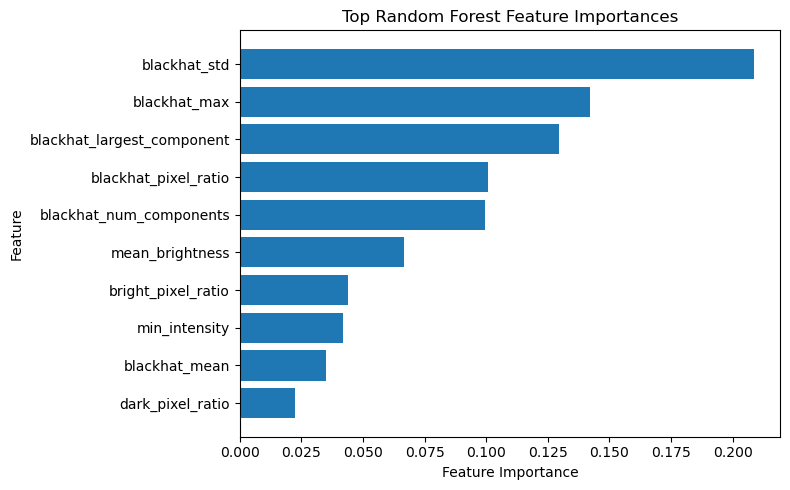

In [67]:

# Plot top feature importances

top_n = 10
plot_df = importance_df.head(top_n).sort_values("Importance")

plt.figure(figsize=(8, 5))
plt.barh(plot_df["Feature"], plot_df["Importance"])
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top Random Forest Feature Importances")
plt.tight_layout()
plt.show()



# Final interpretation

The important conceptual distinction is:

**Folder label → ground truth target**

**OpenCV/NumPy → handcrafted predictor features**

**Traditional ML → learns the relationship between those features and the target**

Therefore, we never create:

```text
if edge_density > X → Crack
```

Instead, the classifier learns from the labeled examples.

### Recommended next improvements

After getting this baseline working, the project can be improved by:
- tuning Canny thresholds systematically
- testing multiple Black Hat kernel sizes
- comparing models with and without Hough
- hyperparameter tuning
- checking class-wise precision/recall
- examining false positives and false negatives
- using cross-validation
